# PLAXIS model, radius, and phase comparison

This notebook is intentionally kept short.  
Most reusable code lives in:

```python
plaxis_compare_tools.py
```

The notebook itself mainly contains:

1. global settings;
2. comparison definitions;
3. execution cells.

This makes it easier to keep an overview and avoids filling the notebook with repeated plotting functions.


In [13]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plaxis_compare_tools as pct

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 100)


In [2]:
# # ============================================================
# # CELL 2 — GLOBAL SETTINGS
# # ============================================================

# # Folder where the PLAXIS Excel result files are stored.
# # If the notebook is in the same folder as the Excel files, keep ".".
RESULTS_FOLDER = Path(r"C:\AA_Thesis\Results\First_sand_layer_tests\Changing_eini_results_excel") # first sand layer results
# RESULTS_FOLDER = Path(r"C:\AA_Thesis\Results\PLAXIS_results\Final_together")  # foundatoin pile sandlayer results

# File naming pattern.
# Files such as:
#   CPT1-2_Linear_PLAXIS_results_R0.45.xlsx
#   CPT1-2_MC_PLAXIS_results_R0.45.xlsx
#   CPT1-2_sanisand_PLAXIS_results_R0.45.xlsx
#   CPT1-2_Linear_PLAXIS_results_R0.25.xlsx
# will be detected automatically.
FILE_PATTERN = "*PLAXIS_results_*.xlsx"

# Sign conventions.
# PLAXIS often reports compression as negative.
# These settings convert stresses and strains to compression-positive values.
STRESS_COMPRESSION_POSITIVE = True
STRAIN_COMPRESSION_POSITIVE = True

# PLAXIS strain shear convention.
# Use "tensor" if epsxy is epsilon_xy.
# Use "engineering" if epsxy is gamma_xy = 2 * epsilon_xy.
SHEAR_STRAIN_CONVENTION = "tensor"

# Depth rounding for selecting measurement points.
Z_ROUND_DECIMALS = 3

# Figure saving.
SAVE_FIGURES = True

FIGURE_FOLDER = Path(r"C:\AA_Thesis\Results\PLAXIS_results\Final_together\Saving_figs")
FIGURE_DPI = 300

# Print the layer/depth table before every comparison.
# Set False once you know the layer/depth selections well.
PRINT_SELECTION_TABLE = True


In [3]:
# ============================================================
# CELL 3 — SCAN AVAILABLE PLAXIS RESULT FILES
# ============================================================

run_catalogue = pct.scan_result_files(
    results_folder=RESULTS_FOLDER,
    file_pattern=FILE_PATTERN,
)

if run_catalogue.empty:
    raise FileNotFoundError(
        f"No files were found in {RESULTS_FOLDER.resolve()} matching {FILE_PATTERN}."
    )

run_catalogue = pct.add_available_phases_to_catalogue(run_catalogue)

print("Detected PLAXIS result files:")
display(run_catalogue)


Detected PLAXIS result files:


,result_id,path,filename,model,radius,eini,plot_label,available_phases,first_phase,last_phase
0,SANISAND_R0.45_eini_0p550,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.550,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.550","[phase_92, phase_93, phase_94, phase_95, phase...",phase_92,phase_100
1,SANISAND_R0.45_eini_0p600,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.600,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.600","[phase_92, phase_93, phase_94, phase_95, phase...",phase_92,phase_100
2,SANISAND_R0.45_eini_0p650,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.650,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.650","[phase_92, phase_93, phase_94, phase_95, phase...",phase_92,phase_100
3,SANISAND_R0.45_eini_0p685,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.685,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.685","[phase_92, phase_93, phase_94, phase_95, phase...",phase_92,phase_99
4,SANISAND_R0.45_eini_0p750,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.750,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.750","[phase_92, phase_93, phase_94, phase_95, phase...",phase_92,phase_97
5,SANISAND_R0.45_eini_0p800,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.800,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.800","[phase_92, phase_93, phase_94]",phase_92,phase_94
6,SANISAND_R0.45_eini_0p850,C:\AA_Thesis\Results\First_sand_layer_tests\Ch...,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.850,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.850",[phase_92],phase_92,phase_92


In [4]:
# ============================================================
# CELL 4 — OPTIONAL: EDIT LEGEND LABELS
# ============================================================

# The automatic labels are usually sufficient.
# If you want shorter or clearer legend labels, edit them here.

# Example:
# run_catalogue = pct.update_plot_label(
#     run_catalogue,
#     result_id="Linear_R0.45",
#     new_label="Linear, R=0.45 m",
# )

display(run_catalogue[["result_id", "model", "radius", "plot_label", "filename"]])


,result_id,model,radius,plot_label,filename
0,SANISAND_R0.45_eini_0p550,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.550",plaxis_soil_input_sanisand_PLAXIS_results_eini...
1,SANISAND_R0.45_eini_0p600,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.600",plaxis_soil_input_sanisand_PLAXIS_results_eini...
2,SANISAND_R0.45_eini_0p650,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.650",plaxis_soil_input_sanisand_PLAXIS_results_eini...
3,SANISAND_R0.45_eini_0p685,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.685",plaxis_soil_input_sanisand_PLAXIS_results_eini...
4,SANISAND_R0.45_eini_0p750,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.750",plaxis_soil_input_sanisand_PLAXIS_results_eini...
5,SANISAND_R0.45_eini_0p800,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.800",plaxis_soil_input_sanisand_PLAXIS_results_eini...
6,SANISAND_R0.45_eini_0p850,SANISAND,0.45,"SANISAND, R = 0.45 m, $e_{ini}$ = 0.850",plaxis_soil_input_sanisand_PLAXIS_results_eini...


## Comparison definitions

You can define one or several comparisons in the list below.

The main modes are:

```python
"models_one_radius"
```

Compare several models for one radius and one phase.

```python
"radii_one_model"
```

Compare several radii within one model and one phase.

```python
"phases_one_model"
```

Compare several phases for one selected model/radius file.

```python
"custom"
```

Manually choose result IDs and phases.

The most important choices are:

```python
### Plot setting options

- `layer`
  - `"auto_bottom_sand"`: automatically selects the deepest layer containing `"sand"` in the layer name.
  - `"auto_deepest"`: automatically selects the deepest available layer.
  - integer, e.g. `1`, `2`, `3`: selects a layer by layer index from the printed layer table.
  - exact layer name, e.g. `"Sand 2"`, `"Clay & silt 1"`: selects a layer by name.

- `depth_point`
  - `"all"`: plots all available depth points in the selected layer.
  - `"shallowest"`: plots the shallowest available point in the selected layer.
  - `"middle"`: plots the middle available point in the selected layer.
  - `"deepest"`: plots the deepest available point in the selected layer.
  - integer, e.g. `1`, `2`, `3`: selects a specific depth point from the printed depth table.

- `components`
  - `"radial_stress"`: radial stress, $\sigma_{rr}$.
  - `"hoop_stress"`: hoop/circumferential stress, $\sigma_{\theta\theta}$.
  - `"radial_shear_stress"`: radial shear stress, $\tau_{r\theta}$.
  - `"radial_strain"`: radial strain, $\varepsilon_{rr}$.
  - `"hoop_strain"`: hoop/circumferential strain, $\varepsilon_{\theta\theta}$.
  - `"radial_shear_strain"`: radial shear strain, $\varepsilon_{r\theta}$.

- `x_axis`
  - `"distance_from_wall"`: distance from the borehole wall in metres.
  - `"radius_from_centre"`: radial distance from the borehole centre in metres.
  - `"r_over_R"`: normalized radial distance from the borehole centre, $r/R$.
  - `"distance_from_wall_over_R"`: normalized distance from the borehole wall, $d/R$; only available if this option was added to `DEFAULT_X_AXES`.

- `title`
  - Any string you want as the main figure title, e.g. `"Bottom sand — SANISAND phase comparison"`.
```


In [5]:
# ============================================================
# CELL 5 — DEFINE COMPARISONS TO RUN
# ============================================================

COMPARISONS = [

    # --------------------------------------------------------
    # A. Compare models at one radius
    # --------------------------------------------------------
    # {
    #     "name": "models_R0.45",
    #     "mode": "models_one_radius",
    #     "radius": 0.45,
    #     "phase": "phase_92",

    #     "layer": "Sand 1",
    #     "depth_point": 3,

    #     "components": [
    #         "radial_stress",
    #         "hoop_stress",
    #         # "radial_strain",
    #         # "hoop_strain",
    #     ],

    #     "component_layout": "separate", # "overlay" or "separate"

    #     "x_axis": "r_over_R",
    #     "depth_layout": "separate",

    #     "title": "First sand — model comparison, R = 0.45 m",
    #     "subtitle": "",
    #     # "ylim": (-0.015, 0.015) # Optional y-axis limits, e.g. to zoom in on a specific range.
    # },

    # --------------------------------------------------------
    # B. Compare different radii within one model
    # This will automatically use all files detected for the
    # selected model, for example R0.25 and R0.45 if both exist.
    # --------------------------------------------------------
    # {
    #     "name": "linear_radius_comparison",
    #     "mode": "radii_one_model",
    #     "model": "Linear Elastic", # Linear Elastic, Mohr-Coulomb, or SANISAND
    #     "phase": "phase_11",

    #     "layer": "auto_bottom_sand",
    #     "depth_point": 2,

    #     "components": [
    #         # "hoop_stress",
    #         # "radial_stress",
    #         "hoop_strain",
    #         "radial_strain",
    #     ],

    #     "component_layout": "overlay", # "overlay" or "separate"

    #     "x_axis": "r_over_R",
    #     "depth_layout": "combined_depths", # separate, combined_depths, or depth_on_x_axis

    #     "title": "Bottom sand — Linear Elastic radius comparison",
    #     "subtitle": "",
    #     "ylim": (-0.022 , 0.022) # Optional y-axis limits, e.g. to zoom in on a specific range.
    # }

    # --------------------------------------------------------
    # C. Compare phases for one selected model/radius file
    # This is useful for seeing how stress/strain evolves during
    # the excavation/unloading phases.
    # --------------------------------------------------------
    # {
    #     "name": "SANISAND_R0.45",
    #     "mode": "phases_one_model",
    #     "result_id": "SANISAND_R0.45",
    #     "phases": [
    #         "phase_1",
    #         "phase_4",
    #         "phase_7",
    #         "phase_8",
    #         "phase_9",
    #         "phase_10",
    #         "phase_11",
    #         # "phase_92",
    #     ],
    
    #     "layer": "Sand_2",
    #     "depth_point": 2,
    
    #     "components": [
    #         # "radial_stress",
    #         # "hoop_stress",
    #         "radial_strain",
    #         "hoop_strain",
    #     ],

    #     "component_layout": "separate", # "overlay" or "separate"
        
    #     "x_axis": "r_over_R",
    #     "depth_layout": "combined_depths", # separate, combined_depths, or depth_on_x_axis
    
    #     "title": "First sand — SANISAND phase comparison",
    #     "subtitle": "",
    #     # "ylim": (0 ,20) # Optional y-axis limits, e.g. to zoom in on a specific range.
    # },

    # --------------------------------------------------------
    # D. Custom comparison
    # Manually choose result IDs and phases.
    # --------------------------------------------------------
    # {
    #     "name": "custom_comparison",
    #     "mode": "custom",
    #     "result_ids": [
    #         "Linear_R0.45",
    #         "MC_R0.45",
    #         "Linear_R0.75",
    #         "MC_R0.75",
    #         # "SANISAND_R0.45",
    #     ],
    #     "phases": ["phase_11"],
    
    #     "layer": "auto_bottom_sand",
    #     "depth_point": 1,  # Use "all" to plot all available depth points for the selected layer 
    
    #     "components": [
    #         "radial_stress",
    #         "radial_strain",
    #         "hoop_stress",
    #         "hoop_strain",
    #     ],
    
    #     "x_axis": "r_over_R",
    #     "depth_layout": "combined_depths",
    
    #     "title": "Bottom sand — custom comparison",
    #     "subtitle": "",
    # },

    # --------------------------------------------------------
    # E. Vertical stress comparison
    # Vertical stress development in different phases.
    # --------------------------------------------------------
    {
        "name": "sanisand_vertical_stress_phase_comparison",
        "mode": "phases_one_model",
        "result_id": "SANISAND_R0.45_eini_0p850",

        "phases": [
            # "phase_1",
            # "phase_4",
            # "phase_7",
            # "phase_9",
            # "phase_11",
            "phase_92"
        ],

        "layer": "sand_1",
        "depth_point": "all",

        "components": [
            "vertical_stress",
        ],

        "x_axis": "r_over_R",
        "depth_layout": "combined_depths", # separate or combined_depths

        "title": "First sand layer — vertical stress phase comparison",
        "subtitle": "",
        "ylim": (0, 30), # Optional y-axis limits, e.g. to zoom in on a specific range.

        # "save_figures": False,
        # "figure_folder": r"C:\AA_Thesis\Results\Numerical",
    },

    
    # # --------------------------------------------------------
    # # F. Compare models at one radius — vertical stress
    # # --------------------------------------------------------
    # {
    #     "name": "models_R0.45_vertical_stress",
    #     "mode": "models_one_radius",
    #     "radius": 0.45,
    #     "phase": "phase_92",

    #     "layer": "Sand 1",
    #     "depth_point": 3,

    #     "components": [
    #         "vertical_stress",
    #     ],

    #     "component_layout": "separate",

    #     "x_axis": "r_over_R",
    #     "depth_layout": "separate",

    #     "title": "First sand — vertical stress model comparison, R = 0.45 m",
    #     "subtitle": "",
    #     "ylim": (0, 30),
    # },
    
]



Comparison: sanisand_vertical_stress_phase_comparison
Available soil layers and PLAXIS measurement depth points
Depth point numbering is shallow to deep within each layer.

[3] Sand_1
    point 1: z = -2.740 m | 34 radial points | distance from wall = 0.020 to 10.000 m
    point 2: z = -3.440 m | 34 radial points | distance from wall = 0.020 to 10.000 m
    point 3: z = -4.140 m | 34 radial points | distance from wall = 0.020 to 10.000 m

Resolved plotting selection:
  result IDs        : ['SANISAND_R0.45_eini_0p850']
  phases            : ['phase_92']
  layer             : [3] Sand_1
  z-values          : [-2.74, -3.44, -4.14]
  components        : ['vertical_stress']
  component layout  : separate
  x-axis            : r_over_R
  depth layout      : combined_depths
Saved: C:\AA_Thesis\Results\PLAXIS_results\Final_together\Saving_figs\vertical_stress_-4.14m_phaseunknown_all_models.png


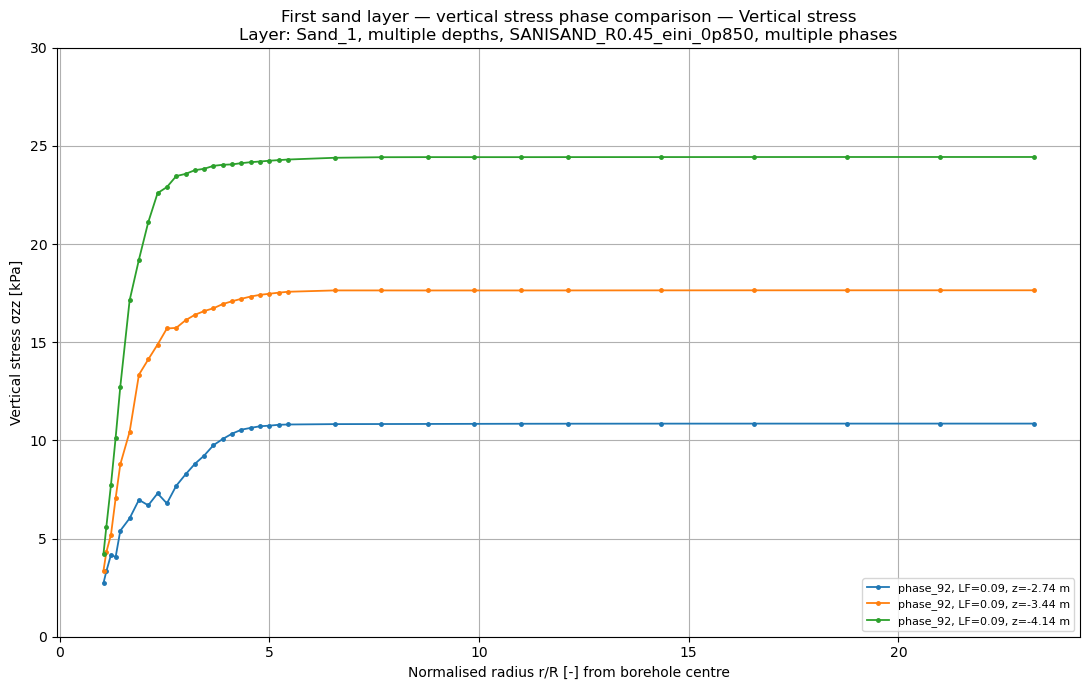

Finished 1 comparison(s).


In [6]:
# ============================================================
# CELL 6 — RUN ALL COMPARISONS
# ============================================================

outputs = pct.run_many_comparisons(
    run_catalogue=run_catalogue,
    comparisons=COMPARISONS,

    stress_compression_positive=STRESS_COMPRESSION_POSITIVE,
    strain_compression_positive=STRAIN_COMPRESSION_POSITIVE,
    shear_strain_convention=SHEAR_STRAIN_CONVENTION,
    z_round_decimals=Z_ROUND_DECIMALS,

    save_figures_default=SAVE_FIGURES,
    figure_folder_default=FIGURE_FOLDER,
    figure_dpi=FIGURE_DPI,

    print_selection_table=PRINT_SELECTION_TABLE,
)

print(f"Finished {len(outputs)} comparison(s).")

## Quick templates

Copy one of the dictionaries below into `COMPARISONS` in Cell 5.


In [7]:
# ============================================================
# CELL 7 — QUICK COMPARISON TEMPLATES
# ============================================================

# Template 1 — compare models at R = 0.45 m
template_models_one_radius = {
    "name": "models_R0.45",
    "mode": "models_one_radius",
    "radius": 0.45,
    "phase": "phase_11",
    "layer": "auto_bottom_sand",
    "depth_point": 1,
    "components": ["radial_stress", "radial_strain"],
    "x_axis": "distance_from_wall",
    "depth_layout": "separate",
    "title": "Bottom sand — model comparison, R = 0.45 m",
    "subtitle": "",
}

# Template 2 — compare radii within Linear Elastic
template_linear_radii = {
    "name": "linear_radii",
    "mode": "radii_one_model",
    "model": "Linear Elastic",
    "phase": "phase_11",
    "layer": "auto_bottom_sand",
    "depth_point": 1,
    "components": ["radial_stress", "radial_strain"],
    "x_axis": "distance_from_wall",
    "depth_layout": "separate",
    "title": "Bottom sand — Linear Elastic radius comparison",
    "subtitle": "",
}

# Template 3 — compare radii within Mohr-Coulomb
template_mc_radii = {
    "name": "mc_radii",
    "mode": "radii_one_model",
    "model": "Mohr-Coulomb",
    "phase": "phase_11",
    "layer": "auto_bottom_sand",
    "depth_point": 1,
    "components": ["radial_stress", "radial_strain"],
    "x_axis": "distance_from_wall",
    "depth_layout": "separate",
    "title": "Bottom sand — Mohr-Coulomb radius comparison",
    "subtitle": "",
}

# Template 4 — compare phases within MC R0.45
template_mc_phases = {
    "name": "mc_R0.45_phases",
    "mode": "phases_one_model",
    "result_id": "MC_R0.45",
    "phases": ["phase_1", "phase_4", "phase_7", "phase_10", "phase_11"],
    "layer": "auto_bottom_sand",
    "depth_point": 1,
    "components": ["radial_stress", "radial_strain"],
    "x_axis": "distance_from_wall",
    "depth_layout": "separate",
    "title": "Bottom sand — Mohr-Coulomb phase comparison",
    "subtitle": "",
}

# Template 5 — compare all depths at bottom sand for one comparison
template_all_depths = {
    "name": "models_R0.45_all_depths",
    "mode": "models_one_radius",
    "radius": 0.45,
    "phase": "phase_11",
    "layer": "auto_bottom_sand",
    "depth_point": "all",
    "components": ["radial_stress", "radial_strain"],
    "x_axis": "distance_from_wall",
    "depth_layout": "combined_depths",
    "title": "Bottom sand — model comparison at all measurement depths",
    "subtitle": "",
}

print("Templates created. Copy any template into COMPARISONS in Cell 5.")


Templates created. Copy any template into COMPARISONS in Cell 5.


In [8]:
# ============================================================
# CELL 8 — OPTIONAL: EXPORT DATA USED IN A COMPARISON
# ============================================================

EXPORT_SELECTED_DATA = False

if EXPORT_SELECTED_DATA:
    for i, output in enumerate(outputs, start=1):
        name = output["comparison"].get("name", f"comparison_{i}")
        export_file = Path(f"selected_data_{name}.xlsx")
        pct.export_selected_plot_data(
            output,
            export_file,
            z_round_decimals=Z_ROUND_DECIMALS,
        )
        print(f"Exported: {export_file}")


## Notes on interpretation

- `sigx`, `sigy`, and `sigxy` are Cartesian PLAXIS stresses.
- The notebook transforms them to radial/hoop components around the borehole:
  - `sig_rr`: radial stress
  - `sig_tt`: hoop stress
  - `tau_rt`: radial-tangential shear stress
- `epsx`, `epsy`, and `epsxy` are transformed in the same way to:
  - `eps_rr`: radial strain
  - `eps_tt`: hoop strain
  - `eps_rt`: radial-tangential shear strain

For comparing different borehole radii:

- use `x_axis = "distance_from_wall"` to compare the same physical offset from the borehole wall;
- use `x_axis = "r_over_R"` to compare the normalized cavity response.


Plotting volumetric strain for:
  layer  : Sand_1
  depths : [-2.74, -3.44, -4.14]
  phases : ['phase_92']


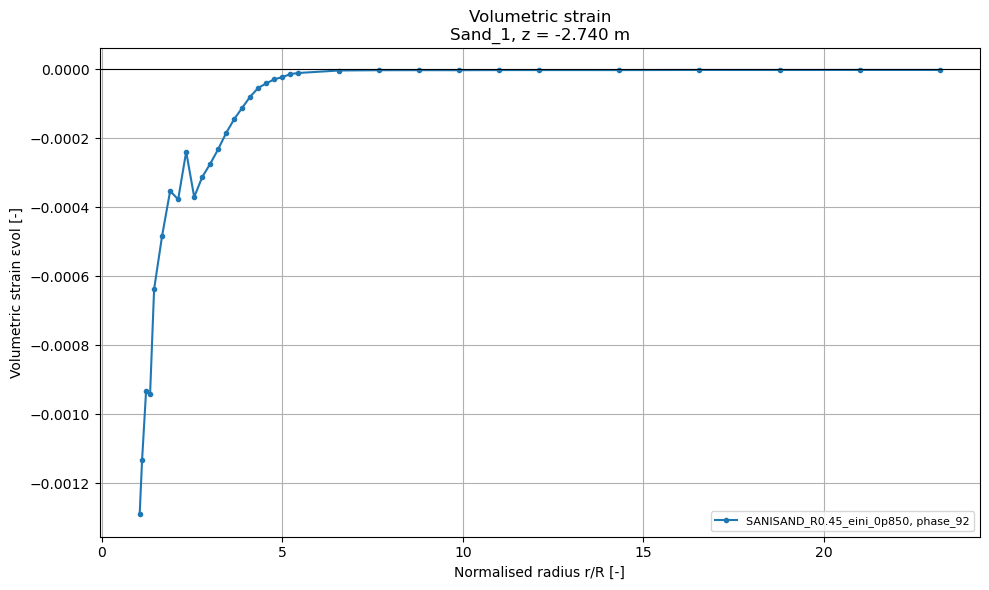

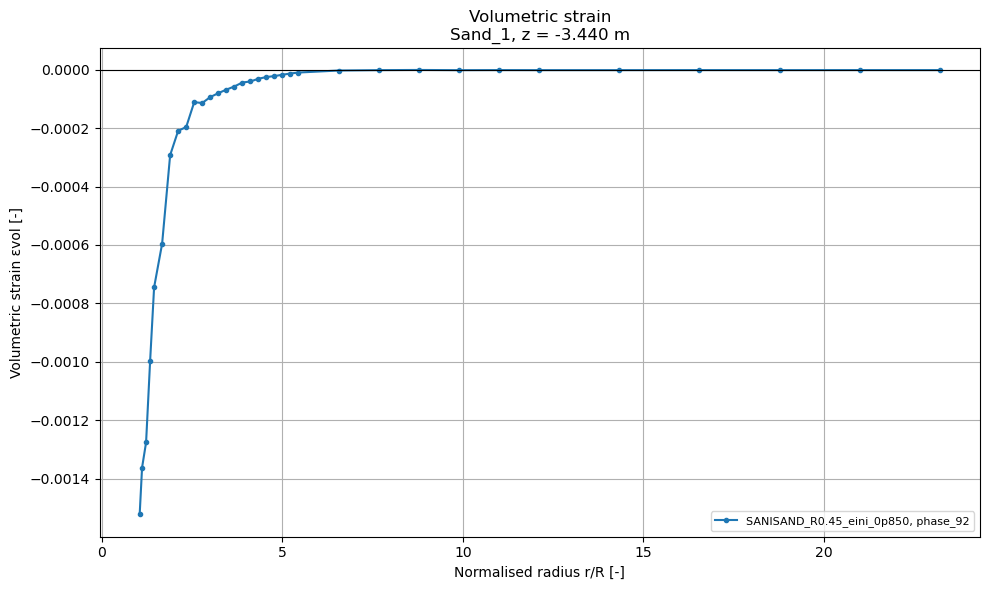

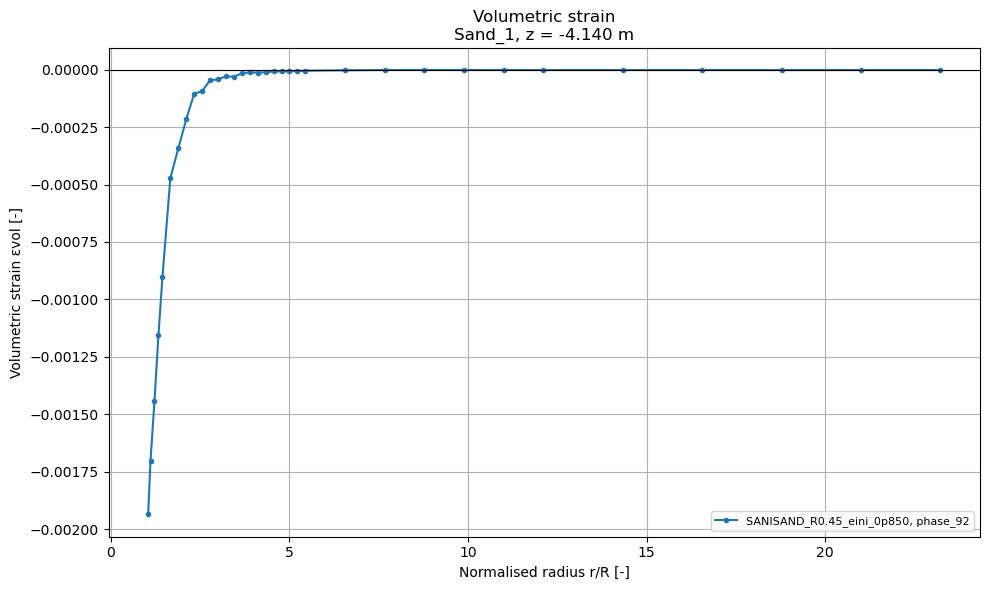

In [9]:
output = outputs[0]

selected_layer_name = output["selected_layer_name"]
selected_layer_index = output["selected_layer_index"]
summary = output["layer_depth_summary"]

# Get all extraction depths of the selected layer
z_values = pct.resolve_depths(
    summary,
    selected_layer_index,
    "all",
)

print("Plotting volumetric strain for:")
print(f"  layer  : {selected_layer_name}")
print(f"  depths : {z_values}")
print(f"  phases : {output['phases']}")

for selected_z in z_values:

    plt.figure(figsize=(10, 6))

    plotted_anything = False

    for (result_id, phase), df in output["transformed"].items():

        df_plot = pct.filter_result_for_layer_depth(
            df,
            selected_layer_name,
            selected_z,
            z_round_decimals=Z_ROUND_DECIMALS,
        ).copy()

        if df_plot.empty:
            continue

        # Convert vertical strain to the same compression-positive convention
        df_plot["eps_zz"] = -pd.to_numeric(df_plot["epsz"], errors="coerce")

        # Volumetric strain
        df_plot["eps_vol"] = (
            df_plot["eps_rr"]
            + df_plot["eps_tt"]
            + df_plot["eps_zz"]
        )

        df_plot = df_plot.dropna(subset=["r_over_R", "eps_vol"])
        df_plot = df_plot.sort_values("r_over_R")

        plt.plot(
            df_plot["r_over_R"],
            df_plot["eps_vol"],
            marker="o",
            markersize=3,
            linewidth=1.5,
            label=f"{result_id}, {phase}",
        )

        plotted_anything = True

    if not plotted_anything:
        plt.close()
        print(f"No data for z = {selected_z:.3f} m")
        continue

    plt.axhline(0, color="black", linewidth=0.8)

    plt.xlabel("Normalised radius r/R [-]")
    plt.ylabel("Volumetric strain εvol [-]")

    plt.title(
        f"Volumetric strain\n"
        f"{selected_layer_name}, z = {selected_z:.3f} m"
    )

    plt.grid(True)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

Selected result files:


,result_id,filename,model,radius,eini
0,SANISAND_R0.45_eini_0p550,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.550
1,SANISAND_R0.45_eini_0p600,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.600
2,SANISAND_R0.45_eini_0p650,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.650
3,SANISAND_R0.45_eini_0p685,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.685
4,SANISAND_R0.45_eini_0p750,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.750
5,SANISAND_R0.45_eini_0p800,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.800
6,SANISAND_R0.45_eini_0p850,plaxis_soil_input_sanisand_PLAXIS_results_eini...,SANISAND,0.45,0.850



Plotting selection:
  phase       : phase_92
  layer       : [3] Sand_1
  depth point : 2
  z           : -3.440 m
  x-axis      : r_over_R


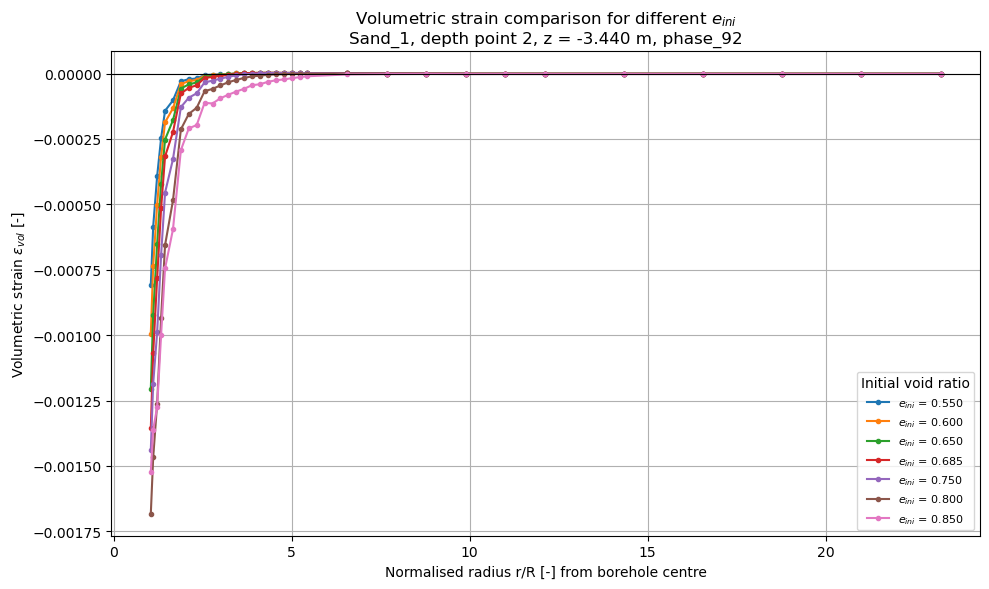

In [10]:
# ============================================================
# COMPARE VOLUMETRIC STRAIN FOR DIFFERENT eini VALUES
# depth point 2, one figure
# ============================================================

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PHASE = "phase_92"          # change if needed
SELECTED_LAYER = "auto_bottom_sand"
DEPTH_POINT = 2             # second measurement depth in the selected layer
X_AXIS = "r_over_R"         # "r_over_R", "distance_from_wall", or "radius_from_centre"

# ------------------------------------------------------------
# SELECT FILES WITH eini VALUES
# ------------------------------------------------------------

selected_runs = run_catalogue[
    run_catalogue["eini"].notna()
].copy()

selected_runs = selected_runs.sort_values("eini")

if selected_runs.empty:
    raise ValueError(
        "No files with eini found in run_catalogue. "
        "Check whether your Excel filenames contain something like eini_0p65."
    )

result_ids = selected_runs["result_id"].to_list()
phases = [PHASE]

print("Selected result files:")
display(selected_runs[["result_id", "filename", "model", "radius", "eini"]])

# ------------------------------------------------------------
# LOAD AND TRANSFORM RESULTS
# ------------------------------------------------------------

loaded = pct.load_result_phases(
    run_catalogue,
    result_ids,
    phases,
)

transformed = pct.transform_loaded_results(
    loaded,
    stress_compression_positive=STRESS_COMPRESSION_POSITIVE,
    strain_compression_positive=STRAIN_COMPRESSION_POSITIVE,
    shear_strain_convention=SHEAR_STRAIN_CONVENTION,
    z_round_decimals=Z_ROUND_DECIMALS,
)

# ------------------------------------------------------------
# RESOLVE LAYER AND DEPTH POINT
# ------------------------------------------------------------

first_key = next(iter(transformed))
reference_df = transformed[first_key]

summary = pct.create_layer_depth_summary(reference_df)

selected_layer_index, selected_layer_name = pct.resolve_layer(
    summary,
    SELECTED_LAYER,
)

selected_z = pct.resolve_depths(
    summary,
    selected_layer_index,
    DEPTH_POINT,
)[0]

x_info = pct.DEFAULT_X_AXES[X_AXIS]
x_col = x_info["column"]

print("")
print("Plotting selection:")
print(f"  phase       : {PHASE}")
print(f"  layer       : [{selected_layer_index}] {selected_layer_name}")
print(f"  depth point : {DEPTH_POINT}")
print(f"  z           : {selected_z:.3f} m")
print(f"  x-axis      : {X_AXIS}")

# ------------------------------------------------------------
# PLOT VOLUMETRIC STRAIN
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plotted_anything = False

for (result_id, phase), df in transformed.items():

    df_plot = pct.filter_result_for_layer_depth(
        df,
        selected_layer_name,
        selected_z,
        z_round_decimals=Z_ROUND_DECIMALS,
    ).copy()

    if df_plot.empty:
        print(f"No data for {result_id}, {phase}, z = {selected_z:.3f} m")
        continue

    if "epsz" not in df_plot.columns:
        raise ValueError(
            f"'epsz' column not found for {result_id}. "
            "Volumetric strain needs eps_rr, eps_tt and epsz."
        )

    # Make vertical strain consistent with eps_rr and eps_tt.
    # Your tool usually uses compression-positive strains.
    if STRAIN_COMPRESSION_POSITIVE:
        df_plot["eps_zz"] = -pd.to_numeric(df_plot["epsz"], errors="coerce")
    else:
        df_plot["eps_zz"] = pd.to_numeric(df_plot["epsz"], errors="coerce")

    df_plot["eps_vol"] = (
        pd.to_numeric(df_plot["eps_rr"], errors="coerce")
        + pd.to_numeric(df_plot["eps_tt"], errors="coerce")
        + pd.to_numeric(df_plot["eps_zz"], errors="coerce")
    )

    df_plot = df_plot.dropna(subset=[x_col, "eps_vol"]).sort_values(x_col)

    if df_plot.empty:
        continue

    eini = selected_runs.loc[
        selected_runs["result_id"] == result_id,
        "eini"
    ].iloc[0]

    label = rf"$e_{{ini}}$ = {eini:.3f}"

    plt.plot(
        df_plot[x_col],
        df_plot["eps_vol"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=label,
    )

    plotted_anything = True

if not plotted_anything:
    raise ValueError("No volumetric strain data could be plotted.")

plt.axhline(0.0, color="black", linewidth=0.8)

plt.xlabel(x_info["xlabel"])
plt.ylabel(r"Volumetric strain $\varepsilon_{vol}$ [-]")

plt.title(
    f"Volumetric strain comparison for different $e_{{ini}}$\n"
    f"{selected_layer_name}, depth point {DEPTH_POINT}, z = {selected_z:.3f} m, {PHASE}"
)

plt.grid(True)
plt.legend(title="Initial void ratio", fontsize=8)
plt.tight_layout()
plt.show()

## Plotting the critical void ratio for Ottawa SANISAND

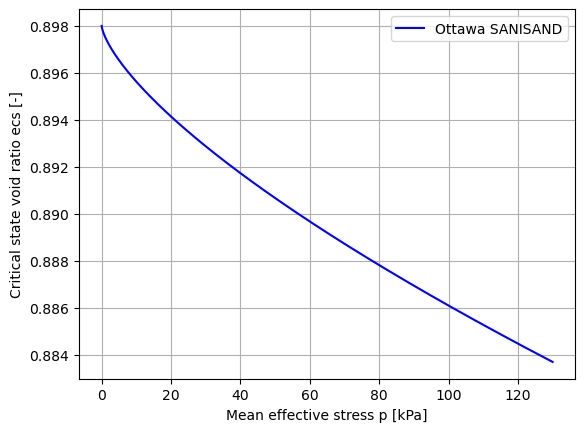

In [17]:
# Ottawa SANISAND parameters
e0 = 0.898
lamb = 0.012 # lambda
Patm = 101.3 # kPa
P = np.linspace(0, 130, 10000)
xi = 0.7

ecs = e0 - lamb *(P / Patm) ** xi

plt.plot(P, ecs, label="Ottawa SANISAND", color="blue")
plt.xlabel("Mean effective stress p [kPa]")
plt.ylabel("Critical state void ratio ecs [-]")
plt.grid()
plt.legend()